<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH04/CH04_NB01_Cosine_Similarity_lmeval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 4: Depth Pruning: Building Smaller and Faster Models

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4

Models:
* Qwen3-0.6B
_____

In this notebook we explore how to evaluate the contribution of different transformer blocks to the LLM's objective using a dataset.

To do this, we use cosine similarity between the input and the output of the transformer block. The lower the similarity, the greater the modification that block has introduced to the data.

Blocks with higher similarity between input and output will be the candidates to be removed from the model.

In this version, calibration is done with **BoolQ** prompts, showing how data-driven pruning preserves task-relevant behavior for reading-comprehension style inputs.

## Setting up notebook

In [1]:
!pip install -q \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "sentence-transformers==5.1.0" \
      "datasets==3.5.0" \
      "optipfair==0.1.5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.4/483.4 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.0 MB/s eta 0:00:00


In [2]:
import torch, random
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM
import os
import json
from copy import deepcopy
from optipfair import analyze_layer_importance, prune_model_depth, prune_model

In [3]:
# ── Global Configuration ─────────────────────────────────────────────────────
MODEL_NAME          = "Qwen/Qwen3-0.6B"
SEED                = 42

# Calibration dataset parameters
CALIBRATION_SAMPLES = 1000
BATCH_SIZE          = 4
MAX_LENGTH          = 512        # BoolQ passages fit comfortably in 512 tokens

# lm_eval parameters
#BENCHMARKS          = ["boolq"]  # Used only for optional quick checks
BENCHMARK_LIMIT            = None         # Samples per benchmark task
NUM_FEWSHOT         = 0
BENCHMARK_TASKS = ['boolq', 'arc_easy', 'winogrande',
                   'hellaswag', 'lambada_openai']

In [4]:
def set_reproducibility(seed=42):
    # 1. Seed for Python and basic libraries
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    # 2. Seed for PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU
    # 3. Configure cuDNN to be deterministic
    # Note: This may slow down training slightly
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # 4. Seed for Transformers (Hugging Face)
    set_seed(seed)
    print(f"\u2705  Seed {seed} stablished.")

set_reproducibility(SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅  Seed 42 stablished.
Using device: cuda
GPU: Tesla T4


In [5]:
def evaluate_metrics(model, dataloader, device='cuda'):
    model.eval()
    model.to(device)
    total_loss = 0
    total_tokens = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            # Create labels, ignoring padding (-100 = ignore_index)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100
            # Forward pass
            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            # Only real tokens (no padding)
            num_real_tokens = attention_mask.sum().item()
            total_loss += outputs.loss.item() * num_real_tokens
            total_tokens += num_real_tokens
    # metrics
    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return {
        'loss': avg_loss,
        'perplexity': perplexity
    }

 ## Load Model

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

## Load Datasets

We use the **BoolQ** dataset for calibration in this notebook. Because pruning decisions are computed from this data distribution, the selected layers reflect BoolQ-style reading-comprehension prompts.

- **BoolQ**: Passage + question requiring reading comprehension. This format exercises contextual understanding across multiple sentences.

The prompts are formatted consistently with the evaluation flow so calibration and downstream comparisons share a similar input style.

In [7]:
# BoolQ: reading comprehension (yes / no)
raw_boolq = load_dataset('boolq', split=f'train[:{CALIBRATION_SAMPLES}]')

def format_boolq(example):
    answer_text = 'yes' if example['answer'] else 'no'
    example['text'] = (
        f"{example['passage']}\n"
        f"Question: {example['question']}?\n"
        f"Answer: {answer_text}"
    )
    return example

databoolq = raw_boolq.map(format_boolq)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [8]:
databoolq[0]

{'question': 'do iran and afghanistan speak the same language',
 'answer': True,
 'passage': 'Persian (/ˈpɜːrʒən, -ʃən/), also known by its endonym Farsi (فارسی fārsi (fɒːɾˈsiː) ( listen)), is one of the Western Iranian languages within the Indo-Iranian branch of the Indo-European language family. It is primarily spoken in Iran, Afghanistan (officially known as Dari since 1958), and Tajikistan (officially known as Tajiki since the Soviet era), and some other regions which historically were Persianate societies and considered part of Greater Iran. It is written in the Persian alphabet, a modified variant of the Arabic script, which itself evolved from the Aramaic alphabet.',
 'text': 'Persian (/ˈpɜːrʒən, -ʃən/), also known by its endonym Farsi (فارسی fārsi (fɒːɾˈsiː) ( listen)), is one of the Western Iranian languages within the Indo-Iranian branch of the Indo-European language family. It is primarily spoken in Iran, Afghanistan (officially known as Dari since 1958), and Tajikistan (off

In [9]:
def prepare_dataset(dataset, text_field='text'):
    def tokenize_function(examples):
        texts = examples[text_field]
        return tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors=None  # Lists, not tensors — avoids torch_formatter
        )
    tokenized = dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)

    # Convert to tensors manually in collate_fn
    def collate_fn(examples):
        input_ids = torch.tensor([e['input_ids'] for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e['attention_mask'] for e in examples], dtype=torch.long)
        return {'input_ids': input_ids, 'attention_mask': attention_mask}

    return DataLoader(tokenized, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Create dataloaders
dataloaderboolq = prepare_dataset(databoolq)  # BoolQ (passage + question prompts)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## 4.2 Static block selection

Static approaches are those based on analyzing the structure and initial weights of the model.

### 4.2.1 Removing first, last, middle blocks

In [10]:
# Based in position.
num_to_remove = 4
num_layers = len(model.model.layers)

# Calculate mid point
mid_point = num_layers // 2

# Calculate start and end
start_remove_index = mid_point - (num_to_remove // 2)
end_remove_index = start_remove_index + num_to_remove

print(f"Number of layers: {num_layers}")
print(f"Layers to remove {num_to_remove}.")
print(f"removing from {start_remove_index} to {end_remove_index - 1}")

pruned_model = deepcopy(model)
layers_before = pruned_model.model.layers[:start_remove_index]
layers_after = pruned_model.model.layers[end_remove_index:]

# Assign layers to the model.
pruned_model.model.layers = layers_before + layers_after
print(f"Layers in pruned model: {len(pruned_model.model.layers)}")
print(f"Removed layers: {num_layers - len(pruned_model.model.layers)}")

metrics_pruned_static_boolq = evaluate_metrics(pruned_model, dataloaderboolq)
metrics_pruned_static_boolq

Number of layers: 28
Layers to remove 4.
removing from 12 to 15
Layers in pruned model: 24
Removed layers: 4


Evaluating: 100%|██████████| 250/250 [00:55<00:00,  4.47it/s]


{'loss': 3.1652824440642258, 'perplexity': np.float64(23.695435722941717)}

In [11]:
# Based in weights
def calculate_layer_magnitude(layer):
    total_magnitude = 0
    for param in layer.parameters():
        total_magnitude += torch.norm(param).item()
    return total_magnitude

# Calculate magnitude for each layer
layer_magnitudes = []
for i, layer in enumerate(model.model.layers):
    magnitude = calculate_layer_magnitude(layer)
    layer_magnitudes.append((i, magnitude))

# Remove layers with lower magnitude
layer_magnitudes.sort(key=lambda x: x[1])  # Sort by magnitude
layers_to_remove = [idx for idx, _ in layer_magnitudes[:4]]  # Remove layers with lower magnitude
print(layers_to_remove)

[8, 2, 7, 6]


In [12]:
def print_sorted_importance(scores):
    for i, (layer, score) in enumerate(sorted(scores.items(), key=lambda x: float(x[1]), reverse=True), 1):
        print(f"Layer {layer:2d}: {float(score):.6f}")

In [13]:
# Normalize each layer's total parameter magnitude by the maximum observed magnitude.
# Using divide-by-max so that 1.0 = the heaviest layer and 0.0 would only occur
# for a truly empty layer (never in practice).
layer_magnitudes_raw = []
for i, layer in enumerate(model.model.layers):
    magnitude = calculate_layer_magnitude(layer)
    layer_magnitudes_raw.append((i, magnitude))

max_magnitude = max(mag for _, mag in layer_magnitudes_raw)
weight_importance = {i: mag / max_magnitude for i, mag in layer_magnitudes_raw}

print("Weight importance (magnitude-based, normalized):")
print_sorted_importance(weight_importance)

Weight importance (magnitude-based, normalized):
Layer 26: 1.000000
Layer 27: 0.988851
Layer 25: 0.897940
Layer 24: 0.773582
Layer 23: 0.660779
Layer 22: 0.617531
Layer 21: 0.586590
Layer 20: 0.523521
Layer 19: 0.499370
Layer 17: 0.472382
Layer 18: 0.457614
Layer 15: 0.424255
Layer  0: 0.424041
Layer 16: 0.408314
Layer 12: 0.391605
Layer 14: 0.390852
Layer  5: 0.390838
Layer  4: 0.387225
Layer  9: 0.384858
Layer 11: 0.384829
Layer 10: 0.383743
Layer 13: 0.383555
Layer  1: 0.377460
Layer  3: 0.374057
Layer  6: 0.372754
Layer  7: 0.371987
Layer  2: 0.367799
Layer  8: 0.361403


In [14]:
magnitude_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=layers_to_remove,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 291415.66it/s]


## 4.3 Data-Driven block selection

To decide which layers to remove, we measure their contribution using cosine similarity. We chose this metric because it's perfect for this task: it measures the change in semantic direction between the input and output vectors of a layer, ignoring their magnitude.

This gives us a normalized score that we convert into an importance score (1 - similarity).

A score close to zero identifies a \"passive\" layer that barely alters the information, making it an ideal candidate for removal.

### 4.3.1 Using PyTorch hooks

We define a simple function to use as a hook that shows the shape of the input tensor and the output tensor.

In [15]:
def print_shape_hook(module, input, output):
    """
    Hook function that prints tensor shapes
    module: the layer where the hook is attached
    input: tuple of input tensors to the layer
    output: the output tensor from the layer
    """
    # Input is a tuple, we take the first element (the hidden states)
    print(f"Module class: {module.__class__.__name__}")
    print(f"Module id: {id(module)}")
    input_tensor = input[0]
    print(f"Input shape:  {input_tensor.shape}")
    print(f"Output shape: {output.shape}")

We register the hook in the first transformer block.

In [16]:
# Register the hook on the first transformer block
first_layer = model.model.layers[0]
hook_handle = first_layer.register_forward_hook(print_shape_hook)

# Test with a simple input
test_text = "He sat on the river bank to fish"
inputs = tokenizer(test_text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

# Remove the hook when done
hook_handle.remove()

# If we run the forward again, the hook no longer executes
with torch.no_grad():
    outputs = model(**inputs)

Module class: Qwen3DecoderLayer
Module id: 133323951461856
Input shape:  torch.Size([1, 8, 1024])
Output shape: torch.Size([1, 8, 1024])


### 4.3.2 Understanding cosine similarity.

In [17]:
from sentence_transformers import SentenceTransformer

# Load standard sentence embedding model
modelst = SentenceTransformer('all-MiniLM-L6-v2')

# Three example sentences: two semantically similar, one different
sentences = [
    "The cat naps on the sofa.",
    "The feline is peacefully slumbering on the couch.",
    "The bus stops at the corner."
]

embeddings = modelst.encode(sentences, convert_to_tensor=True)
print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by {embeddings.shape[1]} dimensions\n")

# Calculate cosine similarity matrix using PyTorch
# We need to compute all pairs, so we use matrix multiplication
# First normalize embeddings
embeddings_normalized = F.normalize(embeddings, p=2, dim=1)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: torch.Size([3, 384])
Each sentence is represented by 384 dimensions



In [18]:
# Compute similarity matrix (cosine = dot product of normalized vectors)
similarity_matrix = torch.mm(embeddings_normalized, embeddings_normalized.T)

print("Cosine Similarity Matrix:")
print(similarity_matrix)
print("\nInterpretation:")
print(f"Sentence 1 vs Sentence 2: {similarity_matrix[0][1]:.4f} (semantically similar)")
print(f"Sentence 1 vs Sentence 3: {similarity_matrix[0][2]:.4f} (different topics)")
print("\nNote: Values close to 1.0 indicate high similarity")

Cosine Similarity Matrix:
tensor([[1.0000, 0.6106, 0.0563],
        [0.6106, 1.0000, 0.0504],
        [0.0563, 0.0504, 1.0000]], device='cuda:0')

Interpretation:
Sentence 1 vs Sentence 2: 0.6106 (semantically similar)
Sentence 1 vs Sentence 3: 0.0563 (different topics)

Note: Values close to 1.0 indicate high similarity


### 4.3.3 Analyzing block contributions with BoolQ calibration data

To capture the input and output of the layers we use PyTorch hooks, which let us study/spy on the model's behavior.

In [19]:
def setup_layer_hooks(model):
    """
    Register hooks to capture input/output of each transformer layer
    Returns: hooks list and storage dictionaries
    """
    num_layers = len(model.model.layers)
    layer_inputs = {}
    layer_outputs = {}
    hooks = []

    def create_hook(layer_idx): #B
        def hook(module, input, output): #C
            input_tensor = input[0] if isinstance(input, tuple) else input
            layer_inputs[layer_idx] = input_tensor.detach() #D
            output_tensor = output[0] if isinstance(output, tuple) else output
            layer_outputs[layer_idx] = output_tensor.detach() #D
        return hook

    # Register hooks for each layer
    for i, layer in enumerate(model.model.layers):
        hooks.append(
            layer.register_forward_hook(create_hook(i))
        )
    return hooks, layer_inputs, layer_outputs, num_layers

 ## Calculate Cosine Similarity

In [20]:
def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    """
    Computes the importance score of an attention sublayer for a single batch,
    properly masking out padding tokens to prevent artificial similarity inflation.
    """
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    # Calculate cosine similarity along the hidden state dimension (dim=-1)
    # Tensors shape: [batch_size, seq_len, hidden_size] -> similarities shape: [batch_size, seq_len]
    similarities = F.cosine_similarity(input_tensor, output_tensor, dim=-1)

    # Ensure the attention mask matches the dimensions and device of the similarities tensor
    attention_mask = attention_mask.to(similarities.device)

    # Zero out similarity scores belonging to padding tokens (where mask is 0)
    valid_similarities = similarities * attention_mask

    # Count only the authentic text tokens present in the current batch
    num_valid_tokens = attention_mask.sum()

    if num_valid_tokens == 0:
        if is_first_batch:
            print(f"Warning: layer {layer_idx} contained only padding tokens in this batch.")
        return 0.0

    # Compute the average similarity strictly across non-padding tokens
    mean_similarity = valid_similarities.sum() / num_valid_tokens

    # Guard against non-finite metrics (NaN/Inf) that corrupt the aggregate results
    if not torch.isfinite(mean_similarity):
        if is_first_batch:
            print(f"Warning: layer {layer_idx} generated non-finite similarity values.")
        return 0.0

    # Importance metric calculation based on Equation 1: S = 1 - CosineSim(X, Y)
    return 1.0 - mean_similarity.item()

We aggregate the results

This function takes the importance scores collected from all data batches for each layer. Then, it computes the average of these scores to get a single final consolidated importance score for each layer of the model.

In [21]:
def calculate_layer_importance_cosine(model, dataloader, device):
    """
    Calculate layer importance using cosine similarity between input/output representations
    Args:
        model: Transformer model
        dataloader: DataLoader with tokenized text data
        device: torch device (cuda/cpu)
    Returns:
        dict: Layer importance scores {layer_idx: importance_score}
    """
    # Setup hooks and storage
    hooks, layer_inputs, layer_outputs, num_layers = setup_layer_hooks(model)
    layer_importance_scores = {i: [] for i in range(num_layers)}

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader,
                                               desc="Processing batches")):
            inputs = {k: v.to(device) for k, v in batch.items()}
            # Forward pass to trigger hooks
            model(**inputs)
            # Calculate importance for each layer
            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Layer {layer_idx} Hook failed.")
                block_importance = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    inputs['attention_mask'],
                    layer_idx,
                    is_first_batch=(batch_idx == 0))
                layer_importance_scores[layer_idx].append(block_importance)
            # Clear storage for next batch
            layer_inputs.clear()
            layer_outputs.clear()

    # Cleanup hooks
    [hook.remove() for hook in hooks]

    # Aggregate final scores
    final_scores = {}
    for layer_idx, scores in layer_importance_scores.items():
        valid_scores = [s for s in scores if np.isfinite(s)]
        if not valid_scores:
            raise RuntimeError(f"Layer {layer_idx} not captured. Hook failed.")
        else:
            final_scores[layer_idx] = np.mean(valid_scores)
    return final_scores

### 4.3.4 Choosing the blocks to discard

In [22]:
boolq_importance = calculate_layer_importance_cosine(model, dataloaderboolq, device)
print("\nBoolQ importance:")
print_sorted_importance(boolq_importance)

Processing batches: 100%|██████████| 250/250 [00:58<00:00,  4.27it/s]


BoolQ importance:
Layer  0: 0.941048
Layer  1: 0.130523
Layer  3: 0.127240
Layer  4: 0.125902
Layer  2: 0.121373
Layer  5: 0.110469
Layer  6: 0.105740
Layer 27: 0.105041
Layer  7: 0.101711
Layer  9: 0.092514
Layer  8: 0.089969
Layer 10: 0.086789
Layer 19: 0.079068
Layer 20: 0.074389
Layer 11: 0.073156
Layer 16: 0.069967
Layer 21: 0.068656
Layer 17: 0.068307
Layer 18: 0.063797
Layer 14: 0.059410
Layer 22: 0.053779
Layer 15: 0.052555
Layer 12: 0.042205
Layer 13: 0.041398
Layer 23: 0.039158
Layer 24: 0.038629
Layer 26: 0.038215
Layer 25: 0.032518


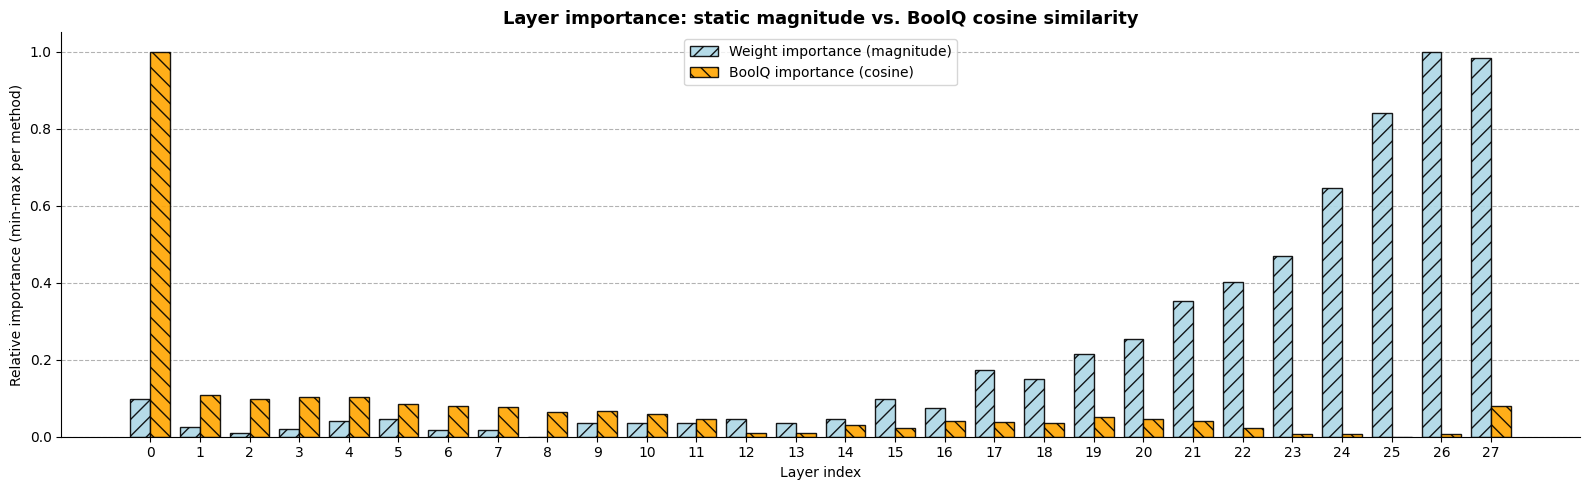

In [23]:
import matplotlib.pyplot as plt
import numpy as np

layers = list(range(len(model.model.layers)))
weight_vals = [weight_importance[i] for i in layers]
boolq_vals  = [boolq_importance[i]  for i in layers]

def minmax(values):
    lo, hi = min(values), max(values)
    return [(v - lo) / (hi - lo) for v in values]

weight_norm = minmax(weight_vals)
boolq_norm  = minmax(boolq_vals)

x     = np.arange(len(layers))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(x - width/2, weight_norm, width,
       label='Weight importance (magnitude)',
       color='lightblue', hatch='//', edgecolor='black', alpha=0.9)
ax.bar(x + width/2, boolq_norm, width,
       label='BoolQ importance (cosine)',
       color='orange', hatch='\\\\', edgecolor='black', alpha=0.9)

ax.set_xlabel('Layer index')
ax.set_ylabel('Relative importance (min-max per method)')
ax.set_title('Layer importance: static magnitude vs. BoolQ cosine similarity',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(layers)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

## Creating models using optipfair.

We'll create a function to select the blocks to delete.

This function can use the protection heuristic, always keeping the first four blocks and the last two. It will also avoid deleting two consecutive blocks.

In [24]:
def select_layers_to_prune(importance_scores,
                            num_layers=2,
                            heuristic_protection=True,
                            adjacent_protection=True):
    """
    Select layers following best practices:
    - Non-consecutive
    - Distributed throughout the model
    - Avoid very early layers (0-2) and the last one (27)
    """
    # Order by importance
    sorted_layers = sorted(importance_scores.items(), key=lambda x: x[1])
    selected = []
    for layer, score in sorted_layers:
        # Skip protected layers
        if heuristic_protection and layer in [0, 1, 2, 3, 26, 27]:
            continue
        # Skip if adjacent
        if adjacent_protection and any(abs(layer - l) == 1 for l in selected):
            continue
        selected.append(layer)
        if len(selected) >= num_layers:
            break
    return selected

In [25]:
boolq_importance = calculate_layer_importance_cosine(model, dataloaderboolq, device)


Processing batches: 100%|██████████| 250/250 [01:03<00:00,  3.94it/s]


In [26]:
# Prune with BoolQ calibration data
boolq_layers_2_remove = select_layers_to_prune(boolq_importance, num_layers=4, heuristic_protection=False, adjacent_protection=False)
print(f"BoolQ layers to remove: {boolq_layers_2_remove}")



BoolQ layers to remove: [25, 26, 24, 23]


In [27]:
boolq_model = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=boolq_layers_2_remove,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 361355.42it/s]


In [38]:
# Prune with BoolQ calibration data
boolq_protected_layers_2_remove = select_layers_to_prune(boolq_importance, num_layers=4, heuristic_protection=True, adjacent_protection=True)
print(f"BoolQ layers to remove: {boolq_protected_layers_2_remove}")

BoolQ layers to remove: [25, 23, 13, 15]


In [29]:
boolq_model_protected = prune_model(
    model=deepcopy(model),
    pruning_type="DEPTH",
    layer_indices=boolq_protected_layers_2_remove,
    show_progress=True,
)

Removing layers: 100%|██████████| 28/28 [00:00<00:00, 342392.16it/s]


## 4.3.5 Analysis of the benchmarks

### lm_eval Evaluation

> We keep a single lm_eval section and evaluate all models on the same benchmark set.

The comparison order is: base model, static pruned models, and BoolQ-pruned models.

In [30]:
def model_evaluation(model_obj, tokenizer, tasks, limit=BENCHMARK_LIMIT):
    """
    Runs lm-eval on a PyTorch model object already in memory.
    Args:
        model_obj: The PyTorch model object to evaluate.
        tokenizer: The tokenizer object.
        tasks (list): A list of task names.
        limit (int): The number of samples per task.
    """
    print(f"Starting lm-eval on model '{model_obj.config._name_or_path}' for tasks: {tasks}")
    # Wrap the local model object and tokenizer for lm-eval
    model_wrapper = HFLM(
        pretrained=model_obj,
        tokenizer=tokenizer,
        device=str(device)
    )
    results = evaluator.simple_evaluate(
        model=model_wrapper,
        tasks=tasks,
        num_fewshot=NUM_FEWSHOT,
        limit=limit,
        device=str(device),
    )
    # Format results for clean display
    formatted_results = {}
    for task_name, res in results["results"].items():
        # Look for accuracy ('acc') first, then perplexity ('ppl')
        if 'acc,none' in res:
            metric_val = res.get('acc,none', 0)
        elif 'acc_norm,none' in res:
            metric_val = res.get('acc_norm,none', 0)
        elif 'ppl,none' in res:
            metric_val = res.get('ppl,none', 0)
        else:
            metric_val = 0
        formatted_results[task_name] = metric_val
    print(json.dumps({k: f"{v:.4f}" for k, v in formatted_results.items()}, indent=2))
    return formatted_results

os.environ["HF_ALLOW_CODE_EVAL"] = "1"

### General benchmarks

In [31]:

os.environ["HF_ALLOW_CODE_EVAL"] = "1"

base_model_results = model_evaluation(model, tokenizer,
                                      BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_position_model_results = model_evaluation(pruned_model, tokenizer,
                                                 BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
static_magnitude_model_results = model_evaluation(magnitude_model,
                                                  tokenizer,
                                                  BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)
boolq_model_results = model_evaluation(boolq_model,
                                       tokenizer,
                                       BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)

boolq_model_protected_results = model_evaluation(boolq_model_protected,
                                                 tokenizer,
                                                 BENCHMARK_TASKS, limit=BENCHMARK_LIMIT)

Starting lm-eval on model 'Qwen/Qwen3-0.6B' for tasks: ['boolq', 'arc_easy', 'winogrande', 'hellaswag', 'lambada_openai']


README.md: 0.00B [00:00, ?B/s]

boolq/train-00000-of-00001.parquet:   0%|          | 0.00/3.85M [00:00<?, ?B/s]

boolq/validation-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

boolq/test-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

...

{
  "arc_easy": "0.3771",
  "boolq": "0.5664",
  "hellaswag": "0.3023",
  "lambada_openai": "0.0413",
  "winogrande": "0.5430"
}
Starting lm-eval on model 'Qwen/Qwen3-0.6B' for tasks: ['boolq', 'arc_easy', 'winogrande', 'hellaswag', 'lambada_openai']


Running loglikelihood requests: 100%|██████████| 63896/63896 [48:14<00:00, 22.07it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:51<00:00,  1.93it/s]


{
  "arc_easy": "0.5088",
  "boolq": "0.6217",
  "hellaswag": "0.3327",
  "lambada_openai": "0.2950",
  "winogrande": "0.5406"
}


In [32]:
print("=" * 50)
print("Base model")
print("=" * 50)
display(base_model_results)

print("\n" + "=" * 50)
print("Static pruned model - position (middle layers)")
print("=" * 50)
display(static_position_model_results)

print("\n" + "=" * 50)
print("Static pruned model - magnitude")
print("=" * 50)
display(static_magnitude_model_results)

print("\n" + "=" * 50)
print("BoolQ pruned model")
print("=" * 50)
display(boolq_model_results)

print("\n" + "=" * 50)
print("BoolQ pruned model (heuristic protection)")
print("=" * 50)
display(boolq_model_protected_results)

Base model


{'arc_easy': 0.6081649831649831,
 'boolq': 0.6452599388379205,
 'hellaswag': 0.37572196773551086,
 'lambada_openai': 0.4036483601785368,
 'winogrande': 0.5603788476716653}


Static pruned model - position (middle layers)


{'arc_easy': 0.5534511784511784,
 'boolq': 0.6214067278287462,
 'hellaswag': 0.3314080860386377,
 'lambada_openai': 0.2571317679021929,
 'winogrande': 0.5232833464877664}


Static pruned model - magnitude


{'arc_easy': 0.2807239057239057,
 'boolq': 0.42996941896024465,
 'hellaswag': 0.2651862178848835,
 'lambada_openai': 0.012808072967203571,
 'winogrande': 0.5193370165745856}


BoolQ pruned model


{'arc_easy': 0.3771043771043771,
 'boolq': 0.5663608562691131,
 'hellaswag': 0.30233021310495917,
 'lambada_openai': 0.04133514457597516,
 'winogrande': 0.5430149960536701}


BoolQ pruned model (heuristic protection)


{'arc_easy': 0.5088383838383839,
 'boolq': 0.6217125382262997,
 'hellaswag': 0.33270264887472617,
 'lambada_openai': 0.2949738016689307,
 'winogrande': 0.5406471981057617}

In [33]:
from IPython.display import Markdown, display

# Retention metrics methodology:
# - BoolQ Retention (%): direct ratio of the model's BoolQ score vs. the base model's BoolQ score.
# - General Capabilities Retention (%): mean of per-task retention ratios across all benchmarks
#   except BoolQ (arc_easy, winogrande, hellaswag, lambada_openai). Each task contributes equally
#   regardless of its absolute score range, avoiding implicit weighting by scale.

model_rows = [
    ("Base model", base_model_results),
    ("Static pruned model - position", static_position_model_results),
    ("Static pruned model - magnitude", static_magnitude_model_results),
    ("BoolQ pruned model", boolq_model_results),
    ("BoolQ pruned model - heuristic protection", boolq_model_protected_results),
]

general_tasks = [t for t in BENCHMARK_TASKS if t != "boolq"]
base_boolq = base_model_results.get("boolq", float("nan"))
base_general = {t: base_model_results.get(t, float("nan")) for t in general_tasks}

header = "| Model | " + " | ".join(BENCHMARK_TASKS) + " | BoolQ Ret. (%) | General Ret. (%) |"
separator = "|---" + "|---" * len(BENCHMARK_TASKS) + "|---|---|"
rows = []

for model_name, result_dict in model_rows:
    metric_values = [f"{result_dict.get(task, float('nan')):.4f}" for task in BENCHMARK_TASKS]

    boolq_score = result_dict.get("boolq", float("nan"))
    boolq_retention = (boolq_score / base_boolq) * 100

    general_retentions = [
        (result_dict.get(t, float("nan")) / base_general[t]) * 100
        for t in general_tasks
    ]
    general_retention = sum(general_retentions) / len(general_retentions)

    rows.append(
        "| " + model_name + " | " +
        " | ".join(metric_values) +
        f" | {boolq_retention:.1f}% | {general_retention:.1f}% |"
    )

markdown_table = "\n".join([header, separator] + rows)
display(Markdown(markdown_table))

| Model | boolq | arc_easy | winogrande | hellaswag | lambada_openai | BoolQ Ret. (%) | General Ret. (%) |
|---|---|---|---|---|---|---|---|
| Base model | 0.6453 | 0.6082 | 0.5604 | 0.3757 | 0.4036 | 100.0% | 100.0% |
| Static pruned model - position | 0.6214 | 0.5535 | 0.5233 | 0.3314 | 0.2571 | 96.3% | 84.1% |
| Static pruned model - magnitude | 0.4300 | 0.2807 | 0.5193 | 0.2652 | 0.0128 | 66.6% | 53.1% |
| BoolQ pruned model | 0.5664 | 0.3771 | 0.5430 | 0.3023 | 0.0413 | 87.8% | 62.4% |
| BoolQ pruned model - heuristic protection | 0.6217 | 0.5088 | 0.5406 | 0.3327 | 0.2950 | 96.4% | 85.4% |

### Measuring Inference Performance Benchmarks

Now we'll measure the inference performance of the pruned models and compare them with the base model. We'll measure:

- **Inference Time**: Total time to process multiple prompts
- **Time to First Token (TTFT)**: Time from input to first generated token
- **Throughput**: Tokens generated per second

In [34]:
import gc
import time

def clear_gpu_cache():
    """Clear GPU cache completely"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 50) -> str:
    """Generate text with the model"""
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            num_return_sequences=1,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=3,
            no_repeat_ngram_size=2
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [35]:
from transformers import StoppingCriteria, StoppingCriteriaList

# Callback class to capture time to first token
class FirstTokenTimeLogger(StoppingCriteria):
    def __init__(self, device):
        self.start_time = time.time()
        self.ttft = None
        self.device = device

    def __call__(self, input_ids, scores, **kwargs):
        # Sync for accurate GPU measurement
        torch.cuda.synchronize(self.device)
        if self.ttft is None:
            # Capture time on the first call (after first token)
            self.ttft = time.time() - self.start_time
        return False  # Return False to not stop generation

def measure_detailed_performance(model, tokenizer, data_source, num_runs=3,
                                 max_new_tokens=50, max_samples=None):
    """
    Measure TTFT and throughput.
    Args:
        data_source: List of prompts (strings) OR DataLoader
        max_samples: Limit number of samples (None = all)
    """
    device = model.device

    # Check if data_source is a DataLoader
    is_dataloader = hasattr(data_source, '__iter__') and hasattr(data_source,
                                                                 'dataset')

    # Extract prompts
    if is_dataloader:
        prompts = []
        for i, batch in enumerate(data_source):
            if max_samples and len(prompts) >= max_samples:
                break
            # Decode batch to text
            input_ids = batch['input_ids']
            for ids in input_ids:
                if max_samples and len(prompts) >= max_samples:
                    break
                ids_no_pad = ids[ids != tokenizer.pad_token_id]
                if len(ids_no_pad) > 0:  # Skip empty sequences
                    prompt = tokenizer.decode(ids_no_pad, skip_special_tokens=True)
                    if prompt.strip():  # Skip empty strings
                        prompts.append(prompt)
    else:
        prompts = data_source

    times = []
    ttfts = []
    throughputs = []

    # Warmup
    print("Warming up model...")
    for _ in range(10):
        inputs = tokenizer("warmup", return_tensors='pt').to(device)
        _ = model.generate(inputs.input_ids, max_new_tokens=max_new_tokens,
                           do_sample=False, pad_token_id=tokenizer.pad_token_id)
    torch.cuda.synchronize(device)

    print(f"Starting measurement with {len(prompts)} prompts...")
    for run in range(num_runs):
        run_times = []
        run_ttfts = []
        run_tokens = []
        for prompt in prompts:
            inputs = tokenizer(prompt, return_tensors='pt').to(device)
            # Skip if input is too short
            if inputs['input_ids'].shape[1] < 2:
                continue
            time_logger = FirstTokenTimeLogger(device)
            torch.cuda.synchronize(device)
            gen_start = time.time()
            with torch.no_grad():
                outputs = model.generate(
                    inputs['input_ids'],
                    attention_mask=inputs['attention_mask'],
                    max_new_tokens=max_new_tokens,
                    pad_token_id=tokenizer.pad_token_id,
                    stopping_criteria=StoppingCriteriaList([time_logger]),
                    do_sample=False,
                )
            torch.cuda.synchronize(device)
            gen_end = time.time()
            total_time = gen_end - gen_start
            num_tokens = outputs.shape[1] - inputs['input_ids'].shape[1]
            run_times.append(total_time)
            run_ttfts.append(time_logger.ttft)
            run_tokens.append(num_tokens)
        times.append(np.mean(run_times))
        ttfts.append(np.mean(run_ttfts))
        throughputs.append(np.sum(run_tokens) / np.sum(run_times))

    return {
        'mean_time_per_prompt': np.mean(times),
        'std_time_per_prompt': np.std(times),
        'mean_ttft': np.mean(ttfts),
        'std_ttft': np.std(ttfts),
        'mean_throughput_tokens_sec': np.mean(throughputs),
        'std_throughput_tokens_sec': np.std(throughputs)
    }

In [36]:
# With BoolQ dataloader
print("Measuring base model on BoolQ...")
base_boolq_timing = measure_detailed_performance(model, tokenizer,
                                                 dataloaderboolq, max_samples=10)

print("\nMeasuring boolq_model on BoolQ...")
boolq_timing = measure_detailed_performance(boolq_model, tokenizer,
                                            dataloaderboolq, max_samples=10)

boolq_speedup = base_boolq_timing['mean_time_per_prompt'] / boolq_timing['mean_time_per_prompt']
print(f"\nBoolQ Model Speedup: {boolq_speedup:.2f}x")

print("\nMeasuring boolq_model_protected on BoolQ...")
boolq_protected_timing = measure_detailed_performance(boolq_model_protected,
                                                      tokenizer,
                                                      dataloaderboolq,
                                                      max_samples=10)

boolq_protected_speedup = base_boolq_timing['mean_time_per_prompt'] / boolq_protected_timing['mean_time_per_prompt']
print(f"\nBoolQ Protected Model Speedup: {boolq_protected_speedup:.2f}x")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Measuring base model on BoolQ...
Warming up model...
Starting measurement with 10 prompts...

Measuring boolq_model on BoolQ...
Warming up model...
Starting measurement with 10 prompts...

BoolQ Model Speedup: 1.11x

Measuring boolq_model_protected on BoolQ...
Warming up model...
Starting measurement with 10 prompts...

BoolQ Protected Model Speedup: 1.12x


In [37]:
# Calculate speedups for inference time
boolq_time_reduction = (base_boolq_timing['mean_time_per_prompt'] - boolq_timing['mean_time_per_prompt']) / base_boolq_timing['mean_time_per_prompt'] * 100
boolq_protected_time_reduction = (base_boolq_timing['mean_time_per_prompt'] - boolq_protected_timing['mean_time_per_prompt']) / base_boolq_timing['mean_time_per_prompt'] * 100

# Calculate speedups for TTFT (lower is better)
boolq_ttft_speedup = base_boolq_timing['mean_ttft'] / boolq_timing['mean_ttft']
boolq_protected_ttft_speedup = base_boolq_timing['mean_ttft'] / boolq_protected_timing['mean_ttft']
boolq_ttft_reduction = (base_boolq_timing['mean_ttft'] - boolq_timing['mean_ttft']) / base_boolq_timing['mean_ttft'] * 100
boolq_protected_ttft_reduction = (base_boolq_timing['mean_ttft'] - boolq_protected_timing['mean_ttft']) / base_boolq_timing['mean_ttft'] * 100

# Calculate speedups for Throughput (higher is better)
boolq_throughput_speedup = boolq_timing['mean_throughput_tokens_sec'] / base_boolq_timing['mean_throughput_tokens_sec']
boolq_protected_throughput_speedup = boolq_protected_timing['mean_throughput_tokens_sec'] / base_boolq_timing['mean_throughput_tokens_sec']
boolq_throughput_improvement = (boolq_timing['mean_throughput_tokens_sec'] - base_boolq_timing['mean_throughput_tokens_sec']) / base_boolq_timing['mean_throughput_tokens_sec'] * 100
boolq_protected_throughput_improvement = (boolq_protected_timing['mean_throughput_tokens_sec'] - base_boolq_timing['mean_throughput_tokens_sec']) / base_boolq_timing['mean_throughput_tokens_sec'] * 100

print(f"\nPerformance Benchmark Results:\n")
print("=" * 70)
print("Base Model (BoolQ prompts):")
print(f"  Inference Time: {base_boolq_timing['mean_time_per_prompt']:.3f}s ± {base_boolq_timing['std_time_per_prompt']:.3f}s")
print(f"  TTFT: {base_boolq_timing['mean_ttft']*1000:.2f}ms ± {base_boolq_timing['std_ttft']*1000:.2f}ms")
print(f"  Throughput: {base_boolq_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {base_boolq_timing['std_throughput_tokens_sec']:.2f}")
print("=" * 70)
print("BoolQ Model (pruned):")
print(f"  Inference Time: {boolq_timing['mean_time_per_prompt']:.3f}s ± {boolq_timing['std_time_per_prompt']:.3f}s")
print(f"    -> Speedup: {boolq_speedup:.2f}x ({boolq_time_reduction:+.1f}%)")
print(f"  TTFT: {boolq_timing['mean_ttft']*1000:.2f}ms ± {boolq_timing['std_ttft']*1000:.2f}ms")
print(f"    -> Speedup: {boolq_ttft_speedup:.2f}x ({boolq_ttft_reduction:+.1f}%)")
print(f"  Throughput: {boolq_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {boolq_timing['std_throughput_tokens_sec']:.2f}")
print(f"    -> Speedup: {boolq_throughput_speedup:.2f}x ({boolq_throughput_improvement:+.1f}%)")
print("=" * 70)
print("BoolQ Model (pruned, heuristic protection):")
print(f"  Inference Time: {boolq_protected_timing['mean_time_per_prompt']:.3f}s ± {boolq_protected_timing['std_time_per_prompt']:.3f}s")
print(f"    -> Speedup: {boolq_protected_speedup:.2f}x ({boolq_protected_time_reduction:+.1f}%)")
print(f"  TTFT: {boolq_protected_timing['mean_ttft']*1000:.2f}ms ± {boolq_protected_timing['std_ttft']*1000:.2f}ms")
print(f"    -> Speedup: {boolq_protected_ttft_speedup:.2f}x ({boolq_protected_ttft_reduction:+.1f}%)")
print(f"  Throughput: {boolq_protected_timing['mean_throughput_tokens_sec']:.2f} tokens/s ± {boolq_protected_timing['std_throughput_tokens_sec']:.2f}")
print(f"    -> Speedup: {boolq_protected_throughput_speedup:.2f}x ({boolq_protected_throughput_improvement:+.1f}%)")


Performance Benchmark Results:

Base Model (BoolQ prompts):
  Inference Time: 2.439s ± 0.022s
  TTFT: 55.16ms ± 0.07ms
  Throughput: 20.50 tokens/s ± 0.19
BoolQ Model (pruned):
  Inference Time: 2.189s ± 0.027s
    -> Speedup: 1.11x (+10.3%)
  TTFT: 49.33ms ± 2.04ms
    -> Speedup: 1.12x (+10.6%)
  Throughput: 22.84 tokens/s ± 0.28
    -> Speedup: 1.11x (+11.4%)
BoolQ Model (pruned, heuristic protection):
  Inference Time: 2.186s ± 0.003s
    -> Speedup: 1.12x (+10.4%)
  TTFT: 50.56ms ± 0.78ms
    -> Speedup: 1.09x (+8.4%)
  Throughput: 22.87 tokens/s ± 0.03
    -> Speedup: 1.12x (+11.6%)
